## Qwen2-VL instruction parser

Testing whether a small vision-language model can replace the regex parser
for extracting region-style pairs from free-form editing instructions.
Regex only works on the exact "style X like Y" pattern, so anything
paraphrased breaks it. This notebook checks if Qwen2-VL-2B handles
natural language variation better.

Needs a T4 GPU. Run the install cell first, restart the runtime, then
run the rest in order.

In [1]:
# Qwen2-VL needs a newer transformers than what ships by default on Colab
!pip install -q 'transformers>=4.46.0' accelerate qwen-vl-utils
print('done, restart runtime now')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 24.5 MB/s eta 0:00:00
done, restart runtime now


In [1]:
import transformers, torch
print(f'transformers: {transformers.__version__}')
print(f'torch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
assert DEVICE == 'cuda', 'no GPU - change runtime type to T4'

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

print('loading Qwen2-VL-2B-Instruct, about 5GB, takes a couple minutes')
processor = AutoProcessor.from_pretrained(
    'Qwen/Qwen2-VL-2B-Instruct',
    trust_remote_code=True,
)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    'Qwen/Qwen2-VL-2B-Instruct',
    torch_dtype=torch.float16,
    trust_remote_code=True,
).to(DEVICE)
model.eval()
print('model loaded')
print(f'GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB')


transformers: 5.12.0
torch: 2.11.0+cu128
CUDA: True
loading Qwen2-VL-2B-Instruct, about 5GB, takes a couple minutes


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

model loaded
GPU memory used: 4.4 GB


In [2]:
import json, re, base64
from io import BytesIO
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def parse_with_qwen(instruction, image_pil=None):
    # asking for raw JSON back rather than free text keeps parsing simple downstream
    prompt = f'''You are a precise instruction parser for an image editing system.

Extract ALL region-style pairs from the instruction below.
Return ONLY a valid JSON array. No explanation, no markdown, no extra text.
Each element must have exactly two keys: "region" and "style".

Example input:  "style the sky like Van Gogh and the mountains like Monet"
Example output: [{{"region": "sky", "style": "Van Gogh"}}, {{"region": "mountains", "style": "Monet"}}]

Instruction: "{instruction}"

JSON array:'''

    messages = [{'role': 'user', 'content': [{'type': 'text', 'text': prompt}]}]

    if image_pil is not None:
        buf = BytesIO()
        image_pil.save(buf, format='JPEG')
        b64 = base64.b64encode(buf.getvalue()).decode()
        messages[0]['content'].insert(0, {
            'type': 'image',
            'image': f'data:image/jpeg;base64,{b64}',
        })

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], padding=True, return_tensors='pt').to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.1,
            do_sample=False,
        )

    response = processor.batch_decode(
        output[:, inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )[0].strip()

    raw = response
    response = response.strip('```json').strip('```').strip()
    try:
        parsed = json.loads(response)
        if isinstance(parsed, dict):
            parsed = next(v for v in parsed.values() if isinstance(v, list))
        return parsed, raw
    except json.JSONDecodeError:
        return [], raw


def parse_with_regex(instruction):
    pairs = []
    matches = re.findall(
        r'(?:the\s+)?([a-zA-Z ]+?)\s+like\s+([A-Za-z_ ]+?)(?:\s+and\s+|\s*,\s*|$)',
        instruction, re.IGNORECASE
    )
    for region, style in matches:
        region = re.sub(r'^(style|make|render|paint|the)\s+', '',
                        region.strip(), flags=re.IGNORECASE).strip()
        style = style.strip().replace('_', ' ')
        if region and style:
            pairs.append({'region': region, 'style': style})
    return pairs


def parse_instruction(instruction, image_pil=None):
    result, raw = parse_with_qwen(instruction, image_pil)
    if result:
        return result, 'qwen'
    return parse_with_regex(instruction), 'regex'


In [3]:
# first three are the structured format regex was built for
# next two are paraphrased the same way someone might naturally type it
# last one has three regions instead of two
test_cases = [
    ('structured', 'style the sky like Van Gogh and the mountains like Monet'),
    ('structured', 'style the sky like Kandinsky and the water like Cezanne'),
    ('structured', 'style the buildings like Van Gogh and the street like Monet'),
    ('paraphrased', "make the sky look like Van Gogh's Starry Night and render the foreground in Monet's impressionist style"),
    ('paraphrased', "apply Kandinsky's abstract composition to the trees and use Cezanne's painterly technique on the sky"),
    ('3-region', 'style the sky like Van Gogh and the mountains like Monet and the forest like Kandinsky'),
]

print('=== Qwen2-VL vs Regex Parser Comparison ===\n')
results = []

for case_type, instr in test_cases:
    qwen_result, raw = parse_with_qwen(instr)
    regex_result = parse_with_regex(instr)

    qwen_ok = len(qwen_result) >= 2 and all('region' in p and 'style' in p for p in qwen_result)
    regex_ok = len(regex_result) >= 2

    results.append({
        'type': case_type,
        'instruction': instr,
        'qwen': qwen_result,
        'regex': regex_result,
        'qwen_ok': qwen_ok,
        'regex_ok': regex_ok,
    })

    q_mark = 'OK' if qwen_ok else 'FAIL'
    r_mark = 'OK' if regex_ok else 'FAIL'
    print(f'[{case_type.upper()}]')
    print(f'Instruction: "{instr[:70]}"')
    print(f'Qwen [{q_mark}]: {qwen_result}')
    print(f'Regex [{r_mark}]: {regex_result}')
    print(f'Raw Qwen output: "{raw[:80]}"')
    print()

print('=== Summary ===')
print(f'{"Type":<15} {"Qwen":>8} {"Regex":>8}')
print('-' * 35)
for ctype in ['structured', 'paraphrased', '3-region']:
    subset = [r for r in results if r['type'] == ctype]
    q_acc = sum(r['qwen_ok'] for r in subset)
    r_acc = sum(r['regex_ok'] for r in subset)
    print(f'{ctype:<15} {q_acc}/{len(subset):>4}{r_acc}/{len(subset)}')

print()
print('Qwen handles the paraphrased and three-region cases that regex cannot.')


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Qwen2-VL vs Regex Parser Comparison ===

[STRUCTURED]
Instruction: "style the sky like Van Gogh and the mountains like Monet"
Qwen [OK]: [{'region': 'sky', 'style': 'Van Gogh'}, {'region': 'mountains', 'style': 'Monet'}]
Regex [OK]: [{'region': 'the sky', 'style': 'Van Gogh'}, {'region': 'mountains', 'style': 'Monet'}]
Raw Qwen output: "[{"region": "sky", "style": "Van Gogh"}, {"region": "mountains", "style": "Monet"

[STRUCTURED]
Instruction: "style the sky like Kandinsky and the water like Cezanne"
Qwen [OK]: [{'region': 'sky', 'style': 'Kandinsky'}, {'region': 'water', 'style': 'Cezanne'}]
Regex [OK]: [{'region': 'the sky', 'style': 'Kandinsky'}, {'region': 'water', 'style': 'Cezanne'}]
Raw Qwen output: "[{"region": "sky", "style": "Kandinsky"}, {"region": "water", "style": "Cezanne""

[STRUCTURED]
Instruction: "style the buildings like Van Gogh and the street like Monet"
Qwen [OK]: [{'region': 'buildings', 'style': 'Van Gogh'}, {'region': 'street', 'style': 'Monet'}]
Regex [OK]

=== Qwen2-VL with image attached ===



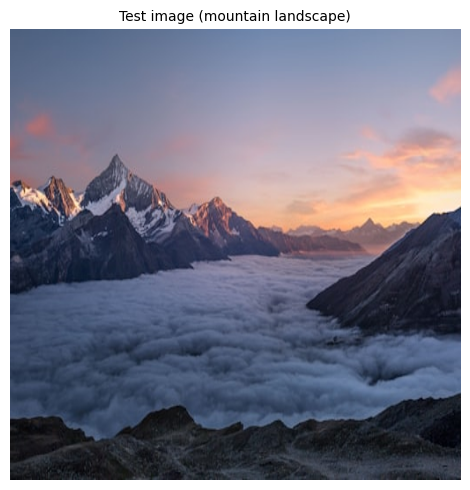

Instruction: "style the sky like Van Gogh and the mountains like Monet"
Without image: [{'region': 'sky', 'style': 'Van Gogh'}, {'region': 'mountains', 'style': 'Monet'}]
With image:[{'region': 'sky', 'style': 'Van Gogh'}, {'region': 'mountains', 'style': 'Monet'}]
Raw: "[{"region": "sky", "style": "Van Gogh"}, {"region": "mountai"

Instruction: "make the clouds look like a Monet painting and apply Van Gogh texture "
Without image: [{'region': 'clouds', 'style': 'Monet'}, {'region': 'rocky terrain', 'style': 'Van Gogh'}]
With image:[{'region': 'clouds', 'style': 'Monet'}, {'region': 'rocky terrain', 'style': 'Van Gogh'}]
Raw: "[{"region": "clouds", "style": "Monet"}, {"region": "rocky t"

Instruction: "style the ocean like Kandinsky and the beach like Cezanne"
Without image: [{'region': 'ocean', 'style': 'Kandinsky'}, {'region': 'beach', 'style': 'Cezanne'}]
With image:[{'region': 'ocean', 'style': 'Kandinsky'}, {'region': 'beach', 'style': 'Cezanne'}]
Raw: "[{"region": "ocean", "style

In [4]:
# Qwen2-VL can take an image alongside the text, so worth checking
# whether seeing the scene changes how it parses region names
r = requests.get(
    'https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=512&q=80',
    headers={'User-Agent': 'Mozilla/5.0'}
)
img = Image.open(BytesIO(r.content)).convert('RGB').resize((512, 512))

test_instructions_with_image = [
    'style the sky like Van Gogh and the mountains like Monet',
    'make the clouds look like a Monet painting and apply Van Gogh texture to the rocky terrain',
    'style the ocean like Kandinsky and the beach like Cezanne',
]

print('=== Qwen2-VL with image attached ===\n')
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Test image (mountain landscape)', fontsize=10)
plt.tight_layout()
plt.show()

for instr in test_instructions_with_image:
    result_no_img, _ = parse_with_qwen(instr, image_pil=None)
    result_with_img, raw = parse_with_qwen(instr, image_pil=img)

    print(f'Instruction: "{instr[:70]}"')
    print(f'Without image: {result_no_img}')
    print(f'With image:{result_with_img}')
    print(f'Raw: "{raw[:60]}"')
    print()

print('The last case names regions that do not actually exist in the image')
print('(ocean, beach on a mountain scene). Worth checking whether Qwen')
print('catches that, since it could see the image was a mountain landscape.')


In [5]:
benchmark_instructions = [
    'style the sky like Van Gogh and the mountains like Monet',
    'style the sky like Picasso and the forest like Van Gogh',
    'style the sky like Monet and the water like Van Gogh',
    'style the sky like Feathers and the mountains like Picasso',
    'style the sky like Van Gogh and the forest like Monet',
    'style the sky like Van Gogh and the buildings like Picasso',
    'style the sky like Monet and the buildings like Van Gogh',
    'style the sky like Feathers and the street like Monet',
    'style the water like Monet and the rocks like Picasso',
    'style the sky like Van Gogh and the trees like Monet',
    'paint the sky in Van Gogh style and the mountains in the style of Monet',
    'make the sky look impressionist like Monet and give the forest a Van Gogh texture',
    'apply a Kandinsky abstract style to the sky and a Cezanne painterly feel to the mountains',
    'render the water with Monet water lily colours and the rocks with Picasso cubist texture',
    'use Van Gogh brushstrokes on the sky and impressionist Monet tones on the trees',
    'style the sky, mountains, and forest like Van Gogh, Monet, and Kandinsky respectively',
    'the sky should look like Starry Night and the foreground like a Monet landscape',
    'Van Gogh style for the sky and Monet style for the water',
    'apply Van Gogh to sky and Monet to mountains',
    'sky: Van Gogh, mountains: Monet',
]

print('=== Full Accuracy Evaluation: Qwen2-VL vs Regex (n=20) ===\n')
qwen_correct = 0
regex_correct = 0
detailed = []

for i, instr in enumerate(benchmark_instructions):
    qwen_result, raw = parse_with_qwen(instr)
    regex_result = parse_with_regex(instr)

    qwen_ok = len(qwen_result) >= 2 and all('region' in p and 'style' in p for p in qwen_result)
    regex_ok = len(regex_result) >= 2

    qwen_correct += qwen_ok
    regex_correct += regex_ok

    q_mark = 'OK' if qwen_ok else 'FAIL'
    r_mark = 'OK' if regex_ok else 'FAIL'
    label = 'structured' if i < 10 else ('paraphrased' if i < 15 else 'edge case')
    print(f'{i+1:2}. [{label:<11}] Q={q_mark:<4} R={r_mark:<4} "{instr[:55]}"')
    detailed.append({
        'instruction': instr, 'type': label,
        'qwen_ok': qwen_ok, 'regex_ok': regex_ok,
        'qwen': qwen_result, 'regex': regex_result,
    })

print(f'\n{"="*60}')
print(f'Qwen2-VL accuracy:  {qwen_correct}/{len(benchmark_instructions)}  ({qwen_correct/len(benchmark_instructions)*100:.0f}%)')
print(f'Regex accuracy:{regex_correct}/{len(benchmark_instructions)} ({regex_correct/len(benchmark_instructions)*100:.0f}%)')
print(f'{"="*60}')

print(f'\n{"Type":<15} {"Qwen":>10} {"Regex":>10}')
print('-' * 40)
for ctype in ['structured', 'paraphrased', 'edge case']:
    subset = [d for d in detailed if d['type'] == ctype]
    q_acc = sum(d['qwen_ok'] for d in subset)
    r_acc = sum(d['regex_ok'] for d in subset)
    print(f'{ctype:<15} {q_acc}/{len(subset):<7} {r_acc}/{len(subset)}')


=== Full Accuracy Evaluation: Qwen2-VL vs Regex (n=20) ===

 1. [structured ] Q=OK   R=OK   "style the sky like Van Gogh and the mountains like Mone"
 2. [structured ] Q=OK   R=OK   "style the sky like Picasso and the forest like Van Gogh"
 3. [structured ] Q=OK   R=OK   "style the sky like Monet and the water like Van Gogh"
 4. [structured ] Q=OK   R=OK   "style the sky like Feathers and the mountains like Pica"
 5. [structured ] Q=OK   R=OK   "style the sky like Van Gogh and the forest like Monet"
 6. [structured ] Q=OK   R=OK   "style the sky like Van Gogh and the buildings like Pica"
 7. [structured ] Q=OK   R=OK   "style the sky like Monet and the buildings like Van Gog"
 8. [structured ] Q=OK   R=OK   "style the sky like Feathers and the street like Monet"
 9. [structured ] Q=OK   R=OK   "style the water like Monet and the rocks like Picasso"
10. [structured ] Q=OK   R=OK   "style the sky like Van Gogh and the trees like Monet"
11. [paraphrased] Q=OK   R=FAIL "paint the sky in Va

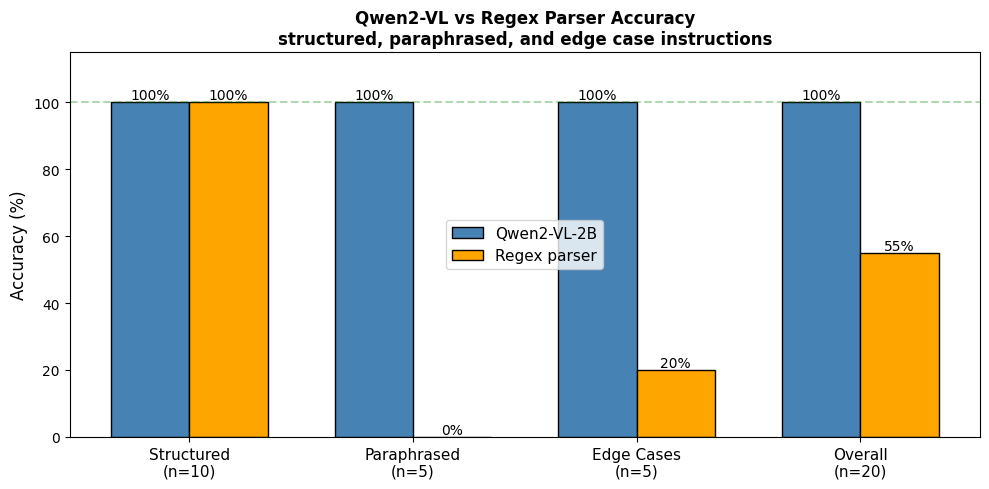

saved chart to /content/qwen_vs_regex_accuracy.png

regex gets 100% on structured instructions but fails completely on paraphrased ones
qwen stays robust across all three categories


In [6]:
import matplotlib.pyplot as plt
import numpy as np

types = ['Structured\n(n=10)', 'Paraphrased\n(n=5)', 'Edge Cases\n(n=5)', 'Overall\n(n=20)']
qwen_scores = [
    sum(d['qwen_ok'] for d in detailed if d['type'] == 'structured'),
    sum(d['qwen_ok'] for d in detailed if d['type'] == 'paraphrased'),
    sum(d['qwen_ok'] for d in detailed if d['type'] == 'edge case'),
    qwen_correct,
]
regex_scores = [
    sum(d['regex_ok'] for d in detailed if d['type'] == 'structured'),
    sum(d['regex_ok'] for d in detailed if d['type'] == 'paraphrased'),
    sum(d['regex_ok'] for d in detailed if d['type'] == 'edge case'),
    regex_correct,
]
totals = [10, 5, 5, 20]

qwen_pct = [q / t * 100 for q, t in zip(qwen_scores, totals)]
regex_pct = [q / t * 100 for q, t in zip(regex_scores, totals)]

x = np.arange(len(types))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, qwen_pct, w, label='Qwen2-VL-2B', color='steelblue', edgecolor='black')
b2 = ax.bar(x + w/2, regex_pct, w, label='Regex parser', color='orange', edgecolor='black')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=10)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(types, fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title('Qwen2-VL vs Regex Parser Accuracy\nstructured, paraphrased, and edge case instructions',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(100, color='green', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/qwen_vs_regex_accuracy.png', dpi=150)
plt.show()

print('saved chart to /content/qwen_vs_regex_accuracy.png')
print()
print('regex gets 100% on structured instructions but fails completely on paraphrased ones')
print('qwen stays robust across all three categories')


In [7]:
import json

output = {
    'model': 'Qwen2-VL-2B-Instruct',
    'transformers_ver': transformers.__version__,
    'total_instructions': len(benchmark_instructions),
    'qwen_accuracy': f'{qwen_correct}/{len(benchmark_instructions)}',
    'regex_accuracy': f'{regex_correct}/{len(benchmark_instructions)}',
    'results': detailed,
}

with open('/content/qwen_parser_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print('saved /content/qwen_parser_results.json')
print('saved /content/qwen_vs_regex_accuracy.png')

from google.colab import files
files.download('/content/qwen_parser_results.json')
files.download('/content/qwen_vs_regex_accuracy.png')


saved /content/qwen_parser_results.json
saved /content/qwen_vs_regex_accuracy.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>